# CNNs with pytorch

To demonstrate the use of Convolutional Neural Networks with Pytorch, we will use an intersting dataset by the name of FashionMNIST. Derived by the spirits of the original [MNIST](https://en.wikipedia.org/wiki/MNIST_database), the fashion reseller Zalando donated a large cohort of product images to the communities for teaching Deep Learning to beginners. See also the [original repository](https://github.com/zalandoresearch/fashion-mnist) of the dataset. `pytorch` can be paired by a `torch` compatible library called `torchvision` which offers several vision related building blocks and datasets.

## Loading FashionMNIST

In [19]:
from torchvision.datasets import FashionMNIST
from torchvision import transforms

In [20]:
transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,))
            ])

In [22]:
train_ds = FashionMNIST(root=".",train=True, download=True, transform=transform)

In [23]:
test_ds = FashionMNIST(root=".",train=False, download=True, transform=transform)

In [24]:
# check how many samples are contained
print(len(train_ds))

60000


In [25]:
print(len(test_ds))

10000


In [30]:
# inspect the first training image
first_X, first_y = train_ds[0]

In [32]:
print("X",first_X.shape, first_X.dtype)
print("y",first_y.shape, first_y.dtype, f"label={first_y.item()}")

X torch.Size([1, 28, 28]) torch.float32
y torch.Size([]) torch.int64 label=9


From the above we learn, that each image is build from 28x28 pixels stored as grey value intensities (as there is only one channel). Each pixel is encoded as `float32`. Further, the labels are encoded as `int64`. Let's try to plot them: 

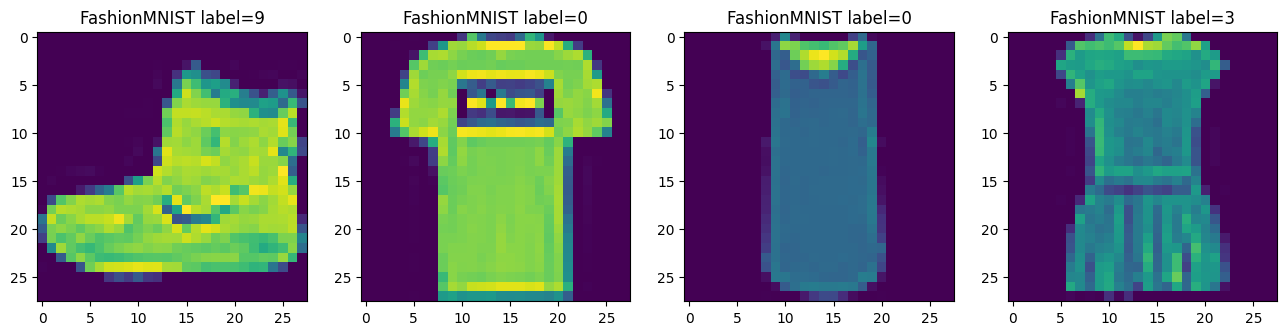

In [41]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots(1,4,figsize=(16,5))

for p in range(4):
    X,y = train_ds[p]
    ax[p].imshow(X[0,...])
    ax[p].set_title(f"FashionMNIST label={y.item()}")

## Defining the model

In [ ]:
from torch import nn
import torch.nn.functional as F

Write a CNN class which consists of:
- a 3x3 convolution with 32 output channels with 1 input channel
- a 3x3 convolution with 32 input channels and 64 output channels
- one dropout layer with rate 0.25
- one dropout layer with rate 0.5
- one linear layers taking going from 9216 inputs to 128 outputs
- one linear layer with 128 inputs and 10 outputs

In [69]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        ...
        
    def forward(self, x):
        ...

## Preparing the training loop

In [70]:
import torch

batch_size = 32
learning_rate = .01

In [71]:
train_loader = torch.utils.data.DataLoader(train_ds,batch_size=batch_size)
test_loader = torch.utils.data.DataLoader(test_ds,batch_size=batch_size)

# fill in the blanks!
model = 
optimizer = torch.optim.Adadelta(...)

In [76]:
def train(args, model, train_loader, optimizer, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data, target
        optimizer.zero_grad()

        #fill in the blanks
        ...
        
        loss.backward()
        optimizer.step()
        if batch_idx % args.log_interval == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(train_loader.dataset),
                100. * batch_idx / len(train_loader), loss.item()))
            if args.dry_run:
                break

In [82]:
def test(model, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data, target
            # fill in the blanks
            ...
            
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

In [83]:
from types import SimpleNamespace

args_ = dict(dry_run = False, log_interval=100, epochs=15)
args = SimpleNamespace(**args_)
args

namespace(dry_run=False, log_interval=50, epochs=30)

In [84]:
for epoch in range(1, args.epochs + 1):
    train(args, model, train_loader, optimizer, epoch)
    test(model, test_loader)

Train Epoch: 1 [0/60000 (0%)]	Loss: 0.353429
Train Epoch: 1 [1600/60000 (3%)]	Loss: 0.497269
Train Epoch: 1 [3200/60000 (5%)]	Loss: 0.584496
Train Epoch: 1 [4800/60000 (8%)]	Loss: 0.436379
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.468567
Train Epoch: 1 [8000/60000 (13%)]	Loss: 0.671728
Train Epoch: 1 [9600/60000 (16%)]	Loss: 0.695168
Train Epoch: 1 [11200/60000 (19%)]	Loss: 0.302490
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.394571
Train Epoch: 1 [14400/60000 (24%)]	Loss: 0.478429
Train Epoch: 1 [16000/60000 (27%)]	Loss: 0.802239
Train Epoch: 1 [17600/60000 (29%)]	Loss: 0.388486
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.375917
Train Epoch: 1 [20800/60000 (35%)]	Loss: 0.762885
Train Epoch: 1 [22400/60000 (37%)]	Loss: 0.199923
Train Epoch: 1 [24000/60000 (40%)]	Loss: 0.595215
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.405935
Train Epoch: 1 [27200/60000 (45%)]	Loss: 0.640867
Train Epoch: 1 [28800/60000 (48%)]	Loss: 0.683802
Train Epoch: 1 [30400/60000 (51%)]	Loss: 0.506146
Train Epoch: 1

In [ ]:
# plot the training and test loss!

We can observe several things from the notebook above:
- convolutions on 28x28 pixel images can be very slow on a CPU
- the network exposes very good accuracy right from the start (85%)
- the flow of the network is similar to the MLP, only that we use Conv+Pool operations instead of linear layers
- we use the same loss function